# Time series prediction using LSTM

## Dataset
- Daily minimum temperatures in Melbourne, Australia, 1981-1990
- Units: Degrees Celcius

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


## Question 1

### Load the data
- load daily-minimum-temperatures-in-me.csv

In [0]:
# if you are using google colab
from google.colab import files
files.upload()

In [0]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [0]:
df = pd.read_csv('/content/drive/My Drive/Machine Learning/Assignments/Internal/Residency 9 internal assignment/daily-minimum-temperatures-in-me.csv')


### Print the data
- First 5 rows only

         Date  Temperature
0  1981-01-01         20.7
1  1981-01-02         17.9
2  1981-01-03         18.8
3  1981-01-04         14.6
4  1981-01-05         15.8


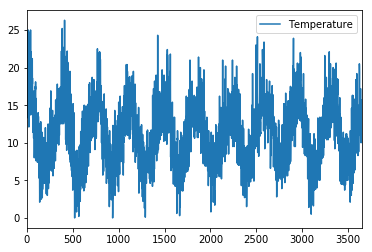

In [5]:
print(df.head())
df.plot()

### Set index column
- Set the DataFrame index using "Date" column

In [0]:
df.index = df['Date']
df = df.drop(['Date'],axis =1)

## Question 2

### Check the total count of null values in the data

In [7]:
df.isnull().values.any()

False

### Drop all the rows with null values
- use dropna() method

## Question 3

### Describe your dataframe
- use describe() method

In [8]:
df.describe()

,Temperature
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


### Plot the dataframe
- use plot() method

### Get representation of the distribution of data using histogram
- use hist() method

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fbc2813acf8>]],
      dtype=object)

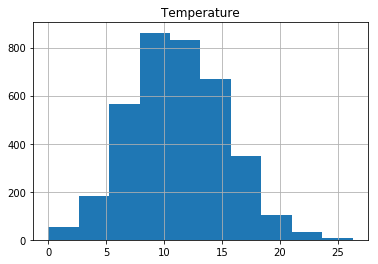

In [9]:
df.hist()

### Check minimum and maximum temperature
- use min() and max() methods

In [11]:
import numpy as np
print('Min', np.min(df['Temperature']))


Min 0.0


In [12]:
print('Max', np.max(df['Temperature']))

Max 26.3


## Question 4

### Split the dataset into training and testing
- training data: 75%
- testing data: 25%

In [0]:
data = df.astype('float32')

In [15]:
train_size = int(len(data) * 0.75)
test_size = len(data - train_size)

train, test = data.iloc[0:train_size, :], data.iloc[train_size: len(data), :]
print('train: {}\ntest: {}'.format(len(train), len(test)))

train: 2737
test: 913


### Normalize the data
- normalize temperature values using MinMaxScaler
- feature_range: 0-1
- fit MinMaxScaler on train data and transform it
  - use fit_transform() method
- transform test data using MinMaxScaler object
  - use transform() method

In [0]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train)
scaled_test = scaler.fit_transform(test)

### Print scaled train and test data
- print only first 5 values

In [19]:
print(scaled_train[:5])

[[0.7870723 ]
 [0.68060837]
 [0.71482889]
 [0.55513311]
 [0.60076048]]


In [18]:
print(scaled_test[:5])

[[0.23504274]
 [0.22649574]
 [0.1880342 ]
 [0.1923077 ]
 [0.33760683]]


## Question 5

### Create sequential data
Map the temperature at a particular day 'd' to the temperature at day t
'd+n', where n is any number you define.

For example: to map temperatures of consecutive days, use d+1, i.e. lookback = 1
- Below function takes data as input and returns sequential data.
- X as features and y as labels

In [0]:
import numpy as np
def create_seq_data(data, lookback=1):
  X, y = list(), list()
  
  for day in range((len(data)-lookback)):
    X.append(data[day: day+lookback, 0])
    y.append(data[day+lookback, 0])
  return np.array(X), np.array(y)

### Use the above function to create train and test sets
- Get X_train and y_train
- Get X_test and y_test
- lookback = 1

In [0]:
X_train , y_train = create_seq_data(scaled_train)
X_test , y_test = create_seq_data(scaled_test)

### Reshape the data
- Reshape X_train and X_test
- use np.reshape() method
- this is to be done to make the data ready for input in model

In [0]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

### Print shape of data
- print shape of X_train and X_test

In [24]:
print(X_train.shape)
print(X_test.shape)

(2736, 1, 1)
(912, 1, 1)


## Question 6

### Define sequential model
- initialize a Sequential model
- add an LSTM layer
  - units: 10
  - stateful: True
  - pass a `batch_input_shape` argument to your layer
  - batch_input_shape: (batch_size, look_back, 1)
    - batch_size: 1
    - look_back: 1
- add Dense layer with 1 neuron

In [25]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.layers import LSTM
from keras  import callbacks
from keras import optimizers

look_back = 1
batch_size = 1
model_sequential = Sequential()
model_sequential.add(LSTM(4, batch_input_shape=(batch_size, look_back, 1), stateful=True))
model_sequential.add(Dense(1))

Using TensorFlow backend.


## Question 7

### compile your model
- loss: mean_squared_error
- optimizer: adam

In [26]:
model_sequential.compile(loss='mean_squared_error', optimizer='adam')

### summarize your model
- use summary() method

In [27]:
model_sequential.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_1 (LSTM)                (1, 4)                    96        
_________________________________________________________________
dense_1 (Dense)              (1, 1)                    5         
Total params: 101
Trainable params: 101
Non-trainable params: 0
_________________________________________________________________


## Question 8

### fit your model
- epochs: 50
- batch_size: 1

In [28]:
model_sequential.fit(X_train, y_train, epochs=50, batch_size=batch_size, verbose=2, shuffle=True)

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where



Epoch 1/50





 - 5s - loss: 0.0159
Epoch 2/50
 - 4s - loss: 0.0132
Epoch 3/50
 - 4s - loss: 0.0118
Epoch 4/50
 - 4s - loss: 0.0107
Epoch 5/50
 - 4s - loss: 0.0103
Epoch 6/50
 - 4s - loss: 0.0101
Epoch 7/50
 - 4s - loss: 0.0101
Epoch 8/50
 - 4s - loss: 0.0100
Epoch 9/50
 - 4s - loss: 0.0101
Epoch 10/50
 - 4s - loss: 0.0100
Epoch 11/50
 - 4s - loss: 0.0101
Epoch 12/50
 - 4s - loss: 0.0101
Epoch 13/50
 - 4s - loss: 0.0101
Epoch 14/50
 - 4s - loss: 0.0101
Epoch 15/50
 - 4s - loss: 0.0101
Epoch 16/50
 - 4s - loss: 0.0100
Epoch 17/50
 - 4s - loss: 0.0101
Epoch 18/50
 - 4s - loss: 0.0100
Epoch 19/50
 - 4s - loss: 0.0099
Epoch 20/50
 - 4s - loss: 0.0100
Epoch 21/50
 - 4s - loss: 0.0101
Epoch 22/50
 - 4s - loss: 0.0100
Epoch 23/50
 - 4s - loss: 0.0100
Epoch 24/50
 - 4s - loss: 0.0101
Epoch 25/50
 - 4s - loss: 0.0101
Epoch 26/50
 - 4s - loss: 0.0100
Epoch 27/50
 - 4s - loss: 0.0100
Epoch 28/50
 - 4

## Question 9

### make predictions on train data
- use predict() method
  - batch_size: 1
- store predictions in a variable

In [29]:
import math
from sklearn.metrics import mean_squared_error

trainPredict = model_sequential.predict(X_train, batch_size=batch_size)
model_sequential.reset_states()

testPredict = model_sequential.predict(X_test, batch_size=batch_size)
# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
y_train = scaler.inverse_transform([y_train])
testPredict = scaler.inverse_transform(testPredict)
y_test = scaler.inverse_transform([y_test])
# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 2.35 RMSE
Test Score: 2.60 RMSE


### reset model state
- if you are using stateful=True in your model then you should call reset_states every time, when you want to make consecutive model calls independent.
- use reset_states() method

### make predictions on test data
- use predict() method
  - batch_size: 1
- store predictions in a variable

## Question 10

### Inverse train predictions and true labels
- use your MinMaxSclarer object
- use inverse_transform() method

### Inverse test predictions and true labels
- use your MinMaxSclarer object
- use inverse_transform() method

### Evaluate train predictions
- calculate RMSE
- RMSE = sqrt(mean_squared_error(true_labels, predicted_labels))
- use sqrt() and mean_squared_error() method
- print training RMSE

### Evaluate test predictions
- calculate RMSE
- RMSE = sqrt(mean_squared_error(true_labels, predicted_labels))
- use sqrt() and mean_squared_error() method
- print testing RMSE